In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import skfuzzy as fuzz
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_swiss_roll
from sklearn.preprocessing import StandardScaler



In [2]:
# ---------------------------
# 1) Preparing the Swiss roll data
# ---------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


def make_swiss_roll_binary(n_samples=3000, swiss_noise=0.4):
    X3d, t = make_swiss_roll(n_samples=n_samples, noise=swiss_noise, random_state=SEED)
    labels = (t > np.median(t)).astype(np.int64)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X3d).astype(np.float32)
    return X_scaled, labels


X, y = make_swiss_roll_binary()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, shuffle=True
)



In [3]:
# ---------------------------
# 2) Fuzzy C-Means for Initialization
# ---------------------------

def fcm_initialize(X, K, m=2.0):
    """Run FCM to obtain rule prototypes."""
    X_t = X.T
    cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
        X_t,
        c=K,
        m=m,
        error=1e-5,
        maxiter=2000,
        init=None,
    )
    N = X.shape[0]

    spreads = []
    for k in range(K):
        weights = u[k].reshape(N, 1)
        diff = X - cntr[k]
        denom = np.sum(weights) + 1e-12
        var = np.sum(weights * (diff ** 2), axis=0) / denom
        spreads.append(np.sqrt(np.clip(var, 1e-6, None)))

    return np.array(cntr, dtype=np.float32), np.array(spreads, dtype=np.float32)



In [4]:
# ---------------------------
# 3) Gaussian MF Layer
# ---------------------------
class GaussianMF_FCM(nn.Module):
    def __init__(self, centers_init, spreads_init):
        super().__init__()
        self.K = centers_init.shape[0]
        self.n_inputs = centers_init.shape[1]
        self.centers = nn.Parameter(torch.tensor(centers_init, dtype=torch.float32))
        self.spreads = nn.Parameter(torch.tensor(spreads_init, dtype=torch.float32))

    def forward(self, x):
        x_exp = x.unsqueeze(1)
        c_exp = self.centers.unsqueeze(0)
        s_exp = torch.nn.functional.softplus(self.spreads).unsqueeze(0)
        s_exp = torch.clamp(s_exp, min=1e-6)
        mu = torch.exp(-((x_exp - c_exp) ** 2) / (2.0 * (s_exp ** 2)))
        firing = torch.prod(mu, dim=2)
        return firing



In [5]:
# ---------------------------
# 4) ANFIS Model With FCM Initialization
# ---------------------------
class ANFIS_FCM(nn.Module):
    def __init__(self, centers_init, spreads_init):
        super().__init__()
        self.K = centers_init.shape[0]
        self.n_inputs = centers_init.shape[1]
        self.mf_layer = GaussianMF_FCM(centers_init, spreads_init)
        self.consequents = nn.Parameter(
            torch.randn(self.K, self.n_inputs + 1, dtype=torch.float32) * 0.1
        )

    def forward(self, x):
        w = self.mf_layer(x)
        w_sum = torch.sum(w, dim=1, keepdim=True) + 1e-8
        w_norm = w / w_sum

        x_exp = x.unsqueeze(1).expand(-1, self.K, -1)
        cons_w = self.consequents[:, :-1].unsqueeze(0)
        linear_part = torch.sum(x_exp * cons_w, dim=2)
        bias = self.consequents[:, -1].unsqueeze(0)
        y_r = linear_part + bias

        y_pred = torch.sum(w_norm * y_r, dim=1, keepdim=True)
        return y_pred



In [6]:
# ---------------------------
# 5) Training (BCE + RMSE tracking)
# ---------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1).to(device)
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)

K = 10
centers_init, spreads_init = fcm_initialize(X_train, K)
model = ANFIS_FCM(centers_init, spreads_init).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.BCEWithLogitsLoss()

n_epochs = 1200
best_loss = float("inf")
best_state = None

for epoch in range(1, n_epochs + 1):
    model.train()
    optimizer.zero_grad()
    logits = model(X_train_tensor)
    loss = loss_fn(logits, y_train_tensor)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
    optimizer.step()

    if loss.item() < best_loss:
        best_loss = loss.item()
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if epoch % 150 == 0 or epoch == 1:
        model.eval()
        with torch.no_grad():
            train_prob = torch.sigmoid(model(X_train_tensor))
            test_prob = torch.sigmoid(model(X_test_tensor))
            train_rmse = torch.sqrt(torch.mean((train_prob - y_train_tensor) ** 2)).item()
            test_rmse = torch.sqrt(torch.mean((test_prob - y_test_tensor) ** 2)).item()
        print(
            f"Epoch {epoch:04d}/{n_epochs}  Loss {loss.item():.4f}  "
            f"Train RMSE {train_rmse:.4f}  Test RMSE {test_rmse:.4f}"
        )

if best_state is not None:
    model.load_state_dict(best_state)
model.eval()

with torch.no_grad():
    final_train_prob = torch.sigmoid(model(X_train_tensor)).cpu().numpy().reshape(-1)
    final_test_prob = torch.sigmoid(model(X_test_tensor)).cpu().numpy().reshape(-1)

train_rmse = np.sqrt(np.mean((final_train_prob - y_train) ** 2))
test_rmse = np.sqrt(np.mean((final_test_prob - y_test) ** 2))
train_acc = np.mean((final_train_prob > 0.5) == y_train)
test_acc = np.mean((final_test_prob > 0.5) == y_test)

print("\nFinal Results:")
print(f"Train RMSE: {train_rmse:.4f}  |  Train Acc: {train_acc:.3f}")
print(f"Test  RMSE: {test_rmse:.4f}  |  Test  Acc: {test_acc:.3f}")



/home/nazanin/.local/lib/python3.10/site-packages/torch/cuda/__init__.py:174: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


Epoch 0001/1200  Loss 0.6865  Train RMSE 0.4965  Test RMSE 0.4968
Epoch 0150/1200  Loss 0.6254  Train RMSE 0.4652  Test RMSE 0.4651
Epoch 0300/1200  Loss 0.5242  Train RMSE 0.4109  Test RMSE 0.4109
Epoch 0450/1200  Loss 0.3805  Train RMSE 0.3268  Test RMSE 0.3281
Epoch 0600/1200  Loss 0.2365  Train RMSE 0.2280  Test RMSE 0.2313
Epoch 0750/1200  Loss 0.1474  Train RMSE 0.1581  Test RMSE 0.1610
Epoch 0900/1200  Loss 0.1003  Train RMSE 0.1167  Test RMSE 0.1202
Epoch 1050/1200  Loss 0.0742  Train RMSE 0.0926  Test RMSE 0.0974
Epoch 1200/1200  Loss 0.0583  Train RMSE 0.0776  Test RMSE 0.0835

Final Results:
Train RMSE: 0.0776  |  Train Acc: 0.999
Test  RMSE: 0.0835  |  Test  Acc: 0.997


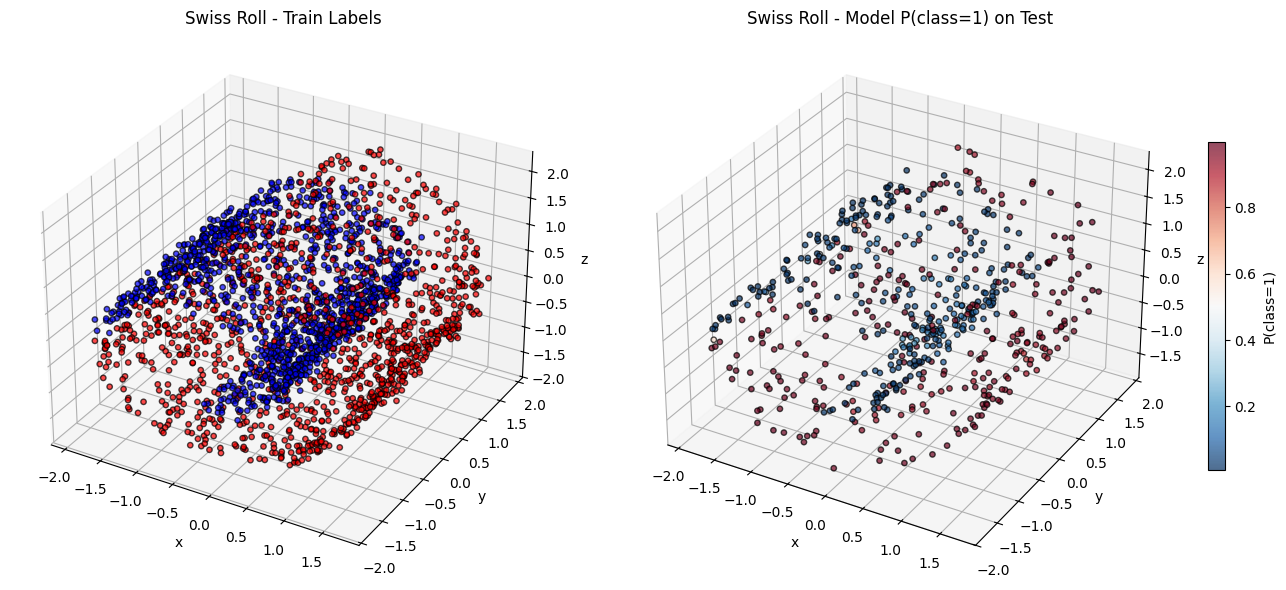

In [7]:
# ---------------------------
# 6) Visualization in 3D space
# ---------------------------
with torch.no_grad():
    train_prob_vis = torch.sigmoid(model(X_train_tensor)).cpu().numpy().reshape(-1)
    test_prob_vis = torch.sigmoid(model(X_test_tensor)).cpu().numpy().reshape(-1)

fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.scatter(
    X_train[:, 0],
    X_train[:, 1],
    X_train[:, 2],
    c=y_train,
    cmap="bwr",
    s=15,
    edgecolor="k",
    alpha=0.7,
)
ax1.set_title("Swiss Roll - Train Labels")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("z")

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
scatter = ax2.scatter(
    X_test[:, 0],
    X_test[:, 1],
    X_test[:, 2],
    c=test_prob_vis,
    cmap="RdBu_r",
    s=15,
    edgecolor="k",
    alpha=0.7,
)
ax2.set_title("Swiss Roll - Model P(class=1) on Test")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("z")
fig.colorbar(scatter, ax=ax2, shrink=0.6, label="P(class=1)")
plt.tight_layout()
plt.show()

